# Notebook A: Candlekeep MVP - Prototype

In this notebook you test whether **Candlekeep’s** routing prototype is strong enough to move forward.

Candlekeep handles **20,000+ customer messages per month**, with roughly **60 hours of manual processing per week** and an average **4.2-hour first response time**. If routing can be automated **safely** and **affordably**, the team can reduce manual effort and speed up handling.

Your job is **not** to prove perfection. Your job is to decide whether this setup is good enough to **continue**, **improve and re-test**, or **stop** — using evidence from a fixed offline evaluation set.

## What this notebook evaluates

1. **Routing quality** — Does the model route to the right department often enough to be useful?
2. **Safety** — If we only automate the safest-looking cases, how risky is that?
3. **Cost** — Is estimated cost acceptable at Candlekeep scale?
4. **Speed** — Is the system fast enough to support a better workflow?

You will **compare** a few candidate models on a sample, **choose** one to study further, then **run a full evaluation** on that model.

## Setup

Install dependencies and load helpers. Run the cell below, then move on to **Settings**.

- **Colab:** the cell installs from GitHub automatically.
- **Local:** replace the install line with `%pip install -q -e .` (from the repo root).

Keep your API key in **Secrets** (Colab) or a local **`.env`** file — avoid committing real keys.

In [2]:
%pip install -q git+https://github.com/mnrozhkov/ai_leader.git
%matplotlib inline

import os

from dotenv import load_dotenv

from ai_leader import *

load_dotenv(override=False)

/Users/mnrozhkov/dev/ai-leader/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


True

## Step 1 — Settings

Set your API key and experiment parameters below.

You can change the **dataset URL** (to use your own data) and **candidate models**. For model comparison we use **30 %** of the rows so runs stay fast; the **full dataset** is used in Step 4.

### API key & parameters

This notebook calls the **Nebius inference API** (OpenAI-compatible).
Get your key at [Nebius AI Studio](https://studio.nebius.ai) → Settings → API Keys.
Store it as a Colab Secret named `NEBIUS_API_KEY`, or add it to a local `.env` file — do **not** paste a real key into the notebook.

**401 error?** Make sure you use a Nebius *inference* API key (not an OpenAI key). See [Nebius API authentication](https://docs.nebius.com/studio/api/authentication) for regional endpoint options.

In [3]:
api_key = setup_api_key()

# Dataset — replace with your own CSV URL or local path to use different data
DATASET_URL = os.getenv(
    "AI_LEADER_DATASET_PATH",
    "https://docs.google.com/spreadsheets/d/e/2PACX-1vSU5zvx8wgk9FMEcRGlCtXkE4_T90OgsrqU4QPNZC478Rsp5JEBEEUjvlMkY3iMoiAmpa1zQ5QFkgT5/pub?output=csv",
)

## Step 2 — Load the evaluation dataset

The CSV holds labeled customer requests with **gold routing targets** (department, category, etc.). We use it to measure how the routing prototype performs beyond a handful of ad-hoc examples.

**Where the file comes from:** the path is set in the previous cell as `DATASET_URL`. By default that is a published Google Sheet CSV URL. To use a **local copy** instead (offline runs or if the URL changes), set the environment variable `AI_LEADER_DATASET_PATH` to a `.csv` file path before running the load cell — the same variable name is read in Settings.

If loading fails, the next cell raises a short error that repeats the URL or path you tried.

In [4]:
df = load_and_validate_dataset(DATASET_URL)
print(f"Rows loaded: {len(df)}")
df.head(3)

Rows loaded: 100


,Request Text,Submission Channel,Related to order,Order ID,Category,Routing to Department,Timestamp,Order History,row_id
0,My Autumn Oak table arrived with a cracked leg...,Email,True,CK-8821,Order Issue,Returns,2025-10-01 09:12:00,2025-09-24 — Order placed | 2025-09-25 — Shipp...,0
1,I need to change my address for order CK-9902....,Chat,True,CK-9902,Delivery,Logistics,2025-09-19 14:00:00,2025-09-12 — Order placed | 2025-09-14 — Shipp...,1
2,Where is my package? The tracking says DPD has...,Social,True,CK-1102,Delivery,Logistics,2025-10-01 10:15:00,2025-09-24 — Order placed | 2025-09-26 — Shipp...,2


**Optional:** inspect how departments are distributed in the reference labels.

In [5]:
df["Routing to Department"].value_counts()

Routing to Department
Logistics           29
Customer Support    27
Product Team        23
Returns             21
Name: count, dtype: int64

In [6]:
df["Category"].value_counts()

Category
Delivery            28
Order Issue         27
General Feedback    24
Payment             21
Name: count, dtype: int64

## Step 3 — Compare candidate models

Run all candidates on a **random 30 % sample** of the dataset and compare them side by side.

### Metrics we compare

| Metric | What it measures | Good direction |
|--------|-----------------|----------------|
| **Department accuracy** | Share of tickets routed to the correct department | Higher is better (main KPI) |
| **Category accuracy** | Share of tickets with the correct category label | Higher is better |
| **Unsafe auto-route rate** | Among tickets the system would auto-route, how many go to the wrong place | Lower is better (safety) |
| **Monthly cost (USD)** | Projected inference spend at 20 000 messages/month | Lower is better |
| **p95 latency (ms)** | 95th-percentile model response time | Lower is better |

**How the best model is chosen:** lowest misroute rate; ties broken by higher department accuracy, then lower cost, then lower latency. You can override the suggestion if you have a reason.



In [7]:
print(DEFAULT_SYSTEM_PROMPT)

You are a support routing assistant.
Return a JSON object with:
- Category
- Routing to Department
- [Agent] Initial Response
- Confidence (High, Medium, Low)
Follow the schema exactly and do not add extra keys.


In [8]:
CANDIDATE_MODELS = [
    "deepseek-ai/DeepSeek-V4-Pro",
    "zai-org/GLM-5.2",
    "openai/gpt-oss-120b",
    "Qwen/Qwen3.5-397B-A17B",
]

model_runs = await run_model_comparison_async(
    df=df.sample(frac=0.3, random_state=42),
    models=CANDIDATE_MODELS,
    api_key=api_key,
    system_prompt=DEFAULT_SYSTEM_PROMPT,
)

Running deepseek-ai/DeepSeek-V4-Pro:   0%|          | 0/30 [00:00<?, ?row/s]

Running zai-org/GLM-5.2:   0%|          | 0/30 [00:00<?, ?row/s]

Running openai/gpt-oss-120b:   0%|          | 0/30 [00:00<?, ?row/s]

Running Qwen/Qwen3.5-397B-A17B:   0%|          | 0/30 [00:00<?, ?row/s]

In [9]:
comparison_df = build_model_comparison_dataframe(df, model_runs)
comparison_df

,model,department_accuracy,category_accuracy,unsafe_auto_route_rate,monthly_cost_usd,p95_latency_ms
0,deepseek-ai/DeepSeek-V4-Pro,0.500,0.533,0.500,1.423,15352.861
1,zai-org/GLM-5.2,0.500,0.533,0.433,30.937,9842.754
2,openai/gpt-oss-120b,0.633,0.567,0.367,3.279,1218.046
3,Qwen/Qwen3.5-397B-A17B,0.667,0.433,0.300,125.416,25145.355


**Optional charts:** quality vs cost (and safety bar chart when there are 2+ models). Figures use `show_figure` so they render once in `inline` backends.

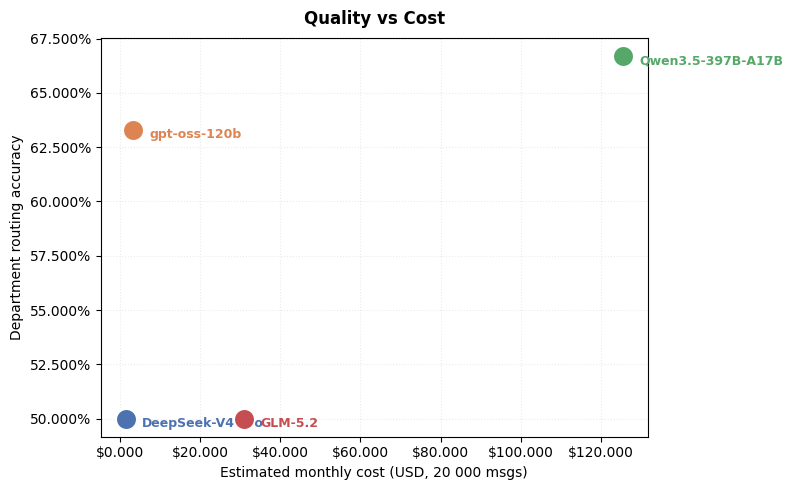

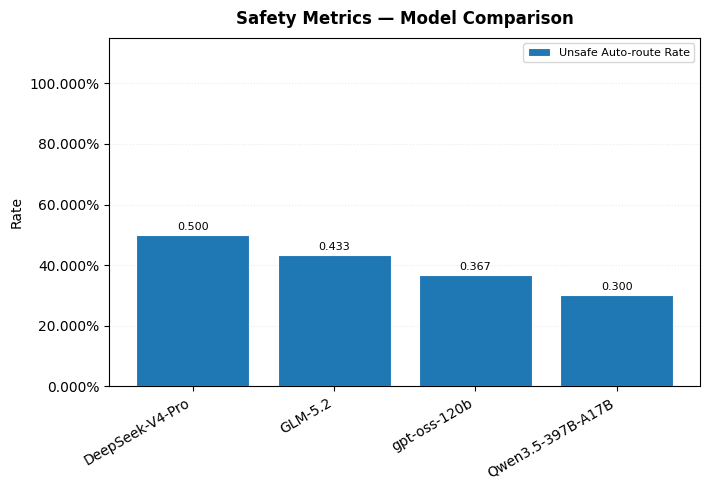

In [10]:
if not comparison_df.empty:
    show_figure(plot_quality_vs_cost(comparison_df))
    show_figure(plot_safety_comparison(comparison_df))

## Step 4 — Run full evaluation on the selected model

Now evaluate **every row** in the dataset with the model you chose. The results are used for the quality, safety, cost, and speed checks in Steps 5-8.

In [11]:
# Select a model for evaluation

BEST_MODEL = select_best_model(model_runs)
print("Suggested model:", BEST_MODEL)

Suggested model: Qwen/Qwen3.5-397B-A17B


In [12]:
# Configure system prompt

SYSTEM_PROMPT = """
You are a support routing assistant.
Return a JSON object with:
- Category
- Routing to Department
- [Agent] Initial Response
- Confidence (High, Medium, Low)
Follow the schema exactly and do not add extra keys.
"""

In [ ]:
client = create_client(api_key, model=BEST_MODEL)

selected_run = await evaluate_model_on_dataframe_async(
    df=df,
    model=BEST_MODEL,
    client=client,
    system_prompt=SYSTEM_PROMPT,
)

Running Qwen/Qwen3.5-397B-A17B:   0%|          | 0/100 [00:00<?, ?row/s]

Row 1 skipped — TimeoutError after 30s
Row 1 failed after retries (TimeoutError: ) — skipping
Row 28 skipped — TimeoutError after 30s
Row 28 failed after retries (TimeoutError: ) — skipping


## Step 5 — Check routing quality

How often does the model route to the correct department and assign the correct category?

Our working target: **>= 85 % department accuracy** before considering the baseline strong enough for the next step.

In [58]:
display_quality_metrics(quality_metrics=selected_run.quality_metrics)

,Department accuracy,Category accuracy,Rows evaluated
0,0.57,0.65,100.0


**What to look for:**
- Is department accuracy close to the 85 % target, or far below?
- If accuracy is low, the baseline prompt likely needs refinement -- that is expected at this stage.
- Check the confusion matrix: are errors concentrated between specific departments (e.g. Returns vs Customer Support)?

## Step 6 — Check safety

**Simple policy:** tickets where the model says **High confidence** are candidates for auto-routing; everything else goes to human review.

Key question: if we auto-route the "High confidence" tickets, how many of them are actually wrong? Our target: **unsafe auto-route rate <= 3 %**.

In [59]:
sm = compute_safety_metrics(df, selected_run.predictions)
display_safety_metrics(safety_metrics=sm)

,Auto-route coverage,Auto-route precision,Unsafe auto-route rate,Manual review rate
0,0.97,0.588,0.4,0.03


**What to look for:**
- If **unsafe auto-route rate is high** (e.g. > 10 %), the model's confidence is poorly calibrated -- it says "High" but is frequently wrong. This means auto-routing is not safe yet.
- Compare **auto-route precision** (accuracy within High-confidence tickets) vs overall **department accuracy**. If the gap is small, confidence is not adding useful signal.
- A high **auto-route coverage** with a high error rate is a warning: the model is overconfident.


## Step 7 — Check cost

How much would it cost to run this model at Candlekeep's volume of **20 000 messages/month**? Our target: **< $1 000/month**. 


In [60]:
display_cost_metrics(cost_metrics=selected_run.cost_metrics)

,"Cost per 1,000 messages (USD)",Monthly cost (USD),Annual cost (USD)
0,0.173,3.452,41.427


The tables below break down cost per message and project monthly/annual totals.

In [61]:
display_cost_breakdown(
    model=BEST_MODEL,
    cost_metrics=selected_run.cost_metrics,
)

,Assumption,Value
0,Model,openai/gpt-oss-120b
1,Messages per month,20000
2,Avg input tokens per message,178.0
3,Avg output tokens per message,243.19
4,Input price (USD / 1M tokens),0.15
5,Output price (USD / 1M tokens),0.6
6,Cost source,measured


,Token type,Avg tokens / message,Price (USD / 1M tokens),Cost / message (USD)
0,Input,178.00,0.15,0.000027
1,Output,243.19,0.60,0.000146
2,Total,421.19,NaN,0.000173


In [62]:
display_cost_projection(
    cost_metrics=selected_run.cost_metrics,
)

,Metric,Value
0,Messages per month,20000.000000
1,Cost per message (USD),0.000173
2,Monthly cost (USD),3.452280
3,Annual cost (USD),41.427360


At 20,000 messages/month, projected cost is $3.45/month (~$41.43/year).


**What to look for:**
- Is the projected monthly cost well within the $1 000 budget, or is it close to the limit?
- Routing calls are usually cheap (short input/output), so cost rarely blocks MVP. But check whether a more expensive model delivers enough quality improvement to justify the difference.

## Step 8 — Check speed

How fast does the model respond? We measure LLM inference latency (not full end-to-end response time). Target: **p95 latency < 5 000 ms**.


In [63]:
display_latency_metrics(latency_metrics=selected_run.latency_metrics)

,Median latency (ms),p95 latency (ms),Latency source
0,1473.093,2028.891,measured


**What to look for:**
- p95 latency above 5 seconds may cause noticeable delays in a real-time workflow. Most routing models respond well under this threshold.
- If latency is high, a smaller or faster model may be worth testing in Notebook B.

## Step 9 — MVP decision

The table below combines all four dimensions (quality, safety, cost, speed) into a single pass/fail summary against the thresholds defined earlier.

In [64]:
decision = evaluate_decision(run=selected_run)
display_mvp_decision(decision=decision)

,Dimension,Status,Value,Pass threshold (≤)
0,Department Accuracy,fail,0.570,0.85
1,Category Accuracy,fail,0.650,0.85
2,Unsafe Auto Route Rate,fail,0.400,0.03
3,Monthly Cost Usd,pass,3.452,1000.00
4,P95 Latency Ms,pass,2028.891,5000.00


## Summary

This notebook established a **baseline**: we measured routing quality, safety, cost, and latency before any optimization.

At this stage, failing one or more thresholds is expected -- the baseline prompt is intentionally simple. The usual next step is **Improve and re-test** (Notebook B). A hard stop is only warranted when constraints clearly cannot be met.

**Next steps in Notebook B:**
- Refine the prompt based on observed mistakes
- Inspect high-confidence errors (calibration issues)
- Improve label quality for ambiguous examples
- Test few-shot examples and analyze trade-offs (quality vs cost/latency)

In short: this notebook defines the gap; Notebook B is where you close it.
